In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams['font.family'] = 'Arial'

from func_data_prep import process_string
from func_modeling import calculate_vif, run_all_diagnostics, try_transformations, recommend_transformation, back_transform_effects
from statsmodels.formula.api import mixedlm

from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Load Metadata

In [2]:
meta = pd.read_csv("../data/meta_meal_patterns.csv")

meta["HEI_Quartile"] = pd.Categorical(
    meta["HEI_Quartile"], categories=["Q1", "Q2", "Q3", "Q4"], ordered=True
)
meta["bmi_cat"] = pd.Categorical(
    meta["bmi_cat"],
    categories=["Underweight", "Normal", "Overweight", "Obese"],
    ordered=True,
)
meta["age_group_2"] = pd.Categorical(
    meta["age_group_2"], categories=["<35", "35-50", ">50"], ordered=True
)

## Load Merged meal data

In [3]:
merged_meals_with_meta = pd.read_pickle("../data/merged_meals_with_meta.pkl")

merged_meals_with_meta["eaten_at"] = pd.to_datetime(merged_meals_with_meta["eaten_at"])
merged_meals_with_meta["eaten_date"] = pd.to_datetime(
    merged_meals_with_meta["eaten_at"].dt.date
)

# # Extract the hour from 'local_eaten_at'
# merged_meals_with_meta['eaten_hour'] = merged_meals_with_meta['local_eaten_at'].dt.hour

print(merged_meals_with_meta.shape)

(65838, 205)


In [4]:
merged_meals_with_meta[merged_meals_with_meta["meal_type"] == "Late_night"].shape

(961, 205)

## Weekend effect on nutrient intake

In [5]:
# def weekend_effect_on_nutrient_by_meal_type(
#     df, target_col, meal_type, covariates, transform=False
# ):
#     """
#     Analyzes the effect of weekdays vs. weekends on a target nutrient for a specific meal type (e.g., 'Dinner').

#     Parameters:
#     - df (pd.DataFrame): The input dataset with required variables.
#     - target_col (str): The column representing the dependent variable (e.g., 'carb_eaten').
#     - meal_type (str): The meal type to analyze (e.g., 'Dinner').
#     - covariates (list): List of covariates to include in the model.

#     Returns:
#     - dict: A dictionary with the model summary, weekend effect results, and the length of the DataFrame used in the model.
#     """
#     # Step 1: Work on a copy of the DataFrame
#     df = df.copy()
#     df = df[df[target_col] >= 0]
#     df = df[df["eaten_quantity_in_gram"] > 0]

#     # Step 2: Add a 'Weekend' indicator variable
#     df["eaten_date"] = pd.to_datetime(
#         df["eaten_date"]
#     )  # Ensure 'eaten_date' is a datetime object
#     df["day_of_week"] = df["eaten_date"].dt.dayofweek
#     # df["is_weekend"] = df.apply(
#     #     lambda row: (
#     #         1
#     #         if (row["eaten_date"].weekday() == 4 and row["eaten_hour"] >= 18)
#     #         or row["eaten_date"].weekday() >= 5
#     #         else 0
#     #     ),
#     #     axis=1,
#     # )
#     df["is_weekend"] = df["day_of_week"].apply(
#         lambda x: "Weekend" if x in [5, 6] else "Weekday"
#     )

#     # Step 3: Filter for the specific meal type
#     meal_df = df[df["meal_type"] == meal_type]
#     if meal_df.empty:
#         return None, None

#     # Step 4: Ensure covariates exist in the filtered DataFrame
#     missing_covariates = [cov for cov in covariates if cov not in meal_df.columns]
#     if missing_covariates:
#         return None, None
#     if target_col not in meal_df.columns:
#         return None, None

#     # Step 5: Create the formula for the model
#     if transform:
#         formula = (
#             f"np.sqrt({target_col}) ~ C(is_weekend, Treatment(reference=0)) + "
#             + " + ".join(covariates)
#         )
#     else:
#         formula = (
#             f"{target_col} ~ C(is_weekend, Treatment(reference=0)) + "
#             + " + ".join(covariates)
#         )

#     # Step 6: Fit a linear mixed-effects model with subject_key as a random effect
#     model = mixedlm(formula, meal_df, groups=meal_df["subject_key"])
#     result = model.fit()

#     # Check for convergence
#     if not result.converged:
#         return None, None

#     # Step 7: Extract the significance of the 'is_weekend' variable
#     weekend_effect_term = "C(is_weekend, Treatment(reference=0))[T.Weekend]"
#     weekend_effect_p_value = result.pvalues[weekend_effect_term]
#     weekend_effect_coefficient = result.params[weekend_effect_term]
#     significance = (
#         "Statistically significant"
#         if weekend_effect_p_value < 0.05
#         else "Not significant"
#     )

#     if transform:
#         weekend_effect_coefficient, weekend_effect_ci_lower, weekend_effect_ci_upper = (
#             back_transform_effects(
#                 meal_df,
#                 weekend_effect_coefficient,
#                 result.bse[weekend_effect_term],
#                 target_col,
#                 meal_df[target_col].mean(),
#             )
#         )

#     return result, {
#         "model_summary": result.summary(),
#         "weekend_effect_coefficient": weekend_effect_coefficient,
#         "weekend_effect_p_value": weekend_effect_p_value,
#         "significance": significance,
#         "dataframe_length": len(meal_df),
#     }

In [6]:
def weekend_effect_on_nutrient_by_meal_type(
    df, target_col, meal_type, covariates, transform=True
):
    """
    Analyzes the effect of weekdays vs. weekends on a target nutrient for a specific meal type (e.g., 'Dinner').

    Parameters:
    - df (pd.DataFrame): The input dataset with required variables.
    - target_col (str): The column representing the dependent variable (e.g., 'carb_eaten').
    - meal_type (str): The meal type to analyze (e.g., 'Dinner').
    - covariates (list): List of covariates to include in the model.

    Returns:
    - dict: A dictionary with the model summary, weekend effect results, and the length of the DataFrame used in the model.
    """
    # Step 1: Work on a copy of the DataFrame
    df = df.copy()
    df = df[df[target_col] >= 0]
    df = df[df["eaten_quantity_in_gram"] > 0]

    # Step 2: Add a 'Weekend' indicator variable
    df["eaten_date"] = pd.to_datetime(
        df["eaten_date"]
    )  # Ensure 'eaten_date' is a datetime object
    df["day_of_week"] = df["eaten_date"].dt.dayofweek
    # df["is_weekend"] = df.apply(
    #     lambda row: (
    #         1
    #         if (row["eaten_date"].weekday() == 4 and row["eaten_hour"] >= 18)
    #         or row["eaten_date"].weekday() >= 5
    #         else 0
    #     ),
    #     axis=1,
    # )
    df["is_weekend"] = df["day_of_week"].apply(
        lambda x: "Weekend" if x in [5, 6] else "Weekday"
    )

    # Step 3: Filter for the specific meal type
    meal_df = df[df["meal_type"] == meal_type]
    if meal_df.empty:
        return None, None

    # Step 4: Ensure covariates exist in the filtered DataFrame
    missing_covariates = [cov for cov in covariates if cov not in meal_df.columns]
    if missing_covariates:
        return None, None
    if target_col not in meal_df.columns:
        return None, None

    # Step 5: Create the formula for the model
    if transform:
        formula = (
            f"np.sqrt({target_col}) ~ C(is_weekend, Treatment(reference=0)) + "
            + " + ".join(covariates)
        )
    else:
        formula = (
            f"{target_col} ~ C(is_weekend, Treatment(reference=0)) + "
            + " + ".join(covariates)
        )

    # Step 6: Fit a linear mixed-effects model with subject_key as a random effect
    model = mixedlm(formula, meal_df, groups=meal_df["subject_key"])
    result = model.fit()

    # Check for convergence
    if not result.converged:
        return None, None

    # Step 7: Extract the significance of the 'is_weekend' variable
    weekend_effect_term = "C(is_weekend, Treatment(reference=0))[T.Weekend]"
    weekend_effect_p_value = result.pvalues[weekend_effect_term]
    weekend_effect_coefficient = result.params[weekend_effect_term]
    significance = (
        "Statistically significant"
        if weekend_effect_p_value < 0.05
        else "Not significant"
    )

    if transform:
        (
            weekend_effect_coefficient,
            weekend_effect_ci_lower,
            weekend_effect_ci_upper,
        ) = back_transform_effects(
            weekend_effect_coefficient,
            result.bse[weekend_effect_term],
            meal_df.groupby("subject_key")[target_col]
            .mean()
            .mean(),  # mean of subject-level means
        )

    return result, {
        "model_summary": result.summary(),
        "weekend_effect_coefficient": weekend_effect_coefficient,
        "weekend_effect_p_value": weekend_effect_p_value,
        "significance": significance,
        "dataframe_length": len(meal_df),
    }

In [7]:
results = []

cols_of_interest = [
    "protein_eaten",
    "carb_eaten",
    "fat_eaten",
    "fiber_eaten",
    "alcohol_eaten",
    "energy_kcal_eaten",
    "iAUC_shifted",
]
cols_of_interest += [
    "vegetables_fruits_x",
    "sweets_salty_snacks_alcohol_x",
    "non_alcoholic_beverages_x",
    "grains_potatoes_pulses_x",
    "oils_fats_nuts_x",
    "beta_carotene_eaten",
    "calcium_eaten",
    "cholesterol_eaten",
    "fatty_acids_monounsaturated_eaten",
    "fatty_acids_polyunsaturated_eaten",
    "fatty_acids_saturated_eaten",
    "folate_eaten",
    "iron_eaten",
    "magnesium_eaten",
    "niacin_eaten",
    "pantothenic_acid_eaten",
    "phosphorus_eaten",
    "potassium_eaten",
    "salt_eaten",
    "sodium_eaten",
    "sugar_eaten",
    "vitamin_b1_eaten",
    "vitamin_b12_eaten",
    "vitamin_b2_eaten",
    "vitamin_b6_eaten",
    "vitamin_c_eaten",
    "vitamin_d_eaten",
    "zinc_eaten",
]

mmm_no_small = merged_meals_with_meta[merged_meals_with_meta["energy_kcal_eaten"] > 0]
mmm_no_small = mmm_no_small[
    ~(mmm_no_small["combined_name"].apply(lambda x: "Tag standardised meal" in x))
]


covariates = [
    "age",
    "bmi",
    "gender",
    "language",
    "smoking",
]
# covariates = ['age', 'bmi', 'gender', 'cohabitants', 'screen_hours', 'language']

for target_col in tqdm(cols_of_interest[:]):
    for meal_type in ["Breakfast", "Lunch", "Dinner", "Late_night"]:
        # result = weekend_effect_on_nutrient_by_meal_type(mmm_no_small, target_col, meal_type, covariates)
        model_fitted, result = weekend_effect_on_nutrient_by_meal_type(
            mmm_no_small[
                mmm_no_small["language"].notna() & mmm_no_small["smoking"].notna()
            ],
            target_col,
            meal_type,
            covariates,
            transform=True,
        )
        if result is not None:
            results.append(
                {
                    "target_col": target_col,
                    "meal_type": meal_type,
                    "weekend_effect_coefficient": result["weekend_effect_coefficient"],
                    "p_value": result["weekend_effect_p_value"],
                    "significance": result["significance"],
                    "dataframe_length": result["dataframe_length"],
                }
            )
            # print(f"{target_col} : {meal_type}: {result['weekend_effect_coefficient']}, {result['weekend_effect_p_value']}, {result['significance']}")
        else:
            print(
                f"{target_col} : {meal_type}: Either no data available or model did not converge"
            )

results_df = pd.DataFrame(results)


def model_significance_to_number(row):
    if row["significance"] != "Statistically significant":
        return 0
    coefficient_direction = 1 if row["weekend_effect_coefficient"] > 0 else -1
    if row["p_value"] < 0.001:
        return coefficient_direction * 3
    elif row["p_value"] < 0.01:
        return coefficient_direction * 2
    elif row["p_value"] < 0.05:
        return coefficient_direction * 1
    else:
        return 0


results_df["is_significant"] = results_df.apply(model_significance_to_number, axis=1)
# results_df['is_significant'] = results_df['p_value'].map(lambda p: 3 if p < 0.001 else (2 if p < 0.01 else (1 if p < 0.05 else 0)))

results_df

 11%|█▏        | 4/35 [00:31<04:19,  8.36s/it]/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/rohansingh/miniconda3/envs/openai_di

alcohol_eaten : Breakfast: Either no data available or model did not converge


 34%|███▍      | 12/35 [01:28<02:06,  5.51s/it]/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWa

vitamin_b1_eaten : Lunch: Either no data available or model did not converge


/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
 83%|████████▎ | 29/35 [03:14<01:01, 10.21s/it]/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWa

,target_col,meal_type,weekend_effect_coefficient,p_value,significance,dataframe_length,is_significant
0,protein_eaten,Breakfast,3.819639e+00,5.384356e-72,Statistically significant,9491,3
1,protein_eaten,Lunch,-2.781594e-01,3.137123e-01,Not significant,20883,0
2,protein_eaten,Dinner,3.177880e-01,1.926537e-01,Not significant,27151,0
3,protein_eaten,Late_night,3.438986e-02,9.614637e-01,Not significant,914,0
4,carb_eaten,Breakfast,1.117188e+01,1.109275e-67,Statistically significant,9491,3
...,...,...,...,...,...,...,...
133,vitamin_d_eaten,Late_night,1.669190e-08,5.581921e-01,Not significant,914,0
134,zinc_eaten,Breakfast,4.017998e-04,5.815082e-42,Statistically significant,9489,3
135,zinc_eaten,Lunch,3.796628e-05,2.302851e-01,Not significant,20865,0
136,zinc_eaten,Dinner,5.960957e-05,4.120954e-02,Statistically significant,27137,1


In [8]:
cols_to_show = [
    "carb_eaten",
    "protein_eaten",
    "fat_eaten",
    "fiber_eaten",
    "salt_eaten",
    "vegetables_fruits_x",
    "sweets_salty_snacks_alcohol_x",
    "non_alcoholic_beverages_x",
    "grains_potatoes_pulses_x",
    "oils_fats_nuts_x",
]
subset = results_df[results_df["target_col"].isin(cols_to_show)]
subset = subset[subset["significance"] != "Not significant"]

subset = subset.set_index("target_col").loc[cols_to_show].reset_index()

subset_pivot = subset.pivot(
    index="target_col", columns="meal_type", values="weekend_effect_coefficient"
)  # .fillna(0)
subset_pivot.index = [i.replace("_x", "") for i in subset_pivot.index]
subset_pivot.index = [process_string(idx) for idx in subset_pivot.index]

subset_pivot = subset_pivot[["Breakfast", "Lunch", "Dinner", "Late_night"]]

subset_pivot

meal_type,Breakfast,Lunch,Dinner,Late_night
Carbohydrate,11.171878,NaN,1.231422,NaN
Fat,5.752957,1.307227,0.661932,NaN
Fiber,0.792041,-0.625232,-0.192293,NaN
Grains Potatoes Pulses,21.780971,-13.797099,NaN,NaN
Non Alcoholic Beverages,16.487372,7.103395,2.288867,8.505752
Oils Fats Nuts,NaN,-1.113263,-0.531716,NaN
Protein,3.819639,NaN,NaN,NaN
Salt,0.300603,-0.044036,NaN,NaN
Sweets Salty Snacks Alcohol,6.441818,13.173009,13.995185,16.324115
Vegetables Fruits,4.042006,-19.393447,-5.677816,NaN


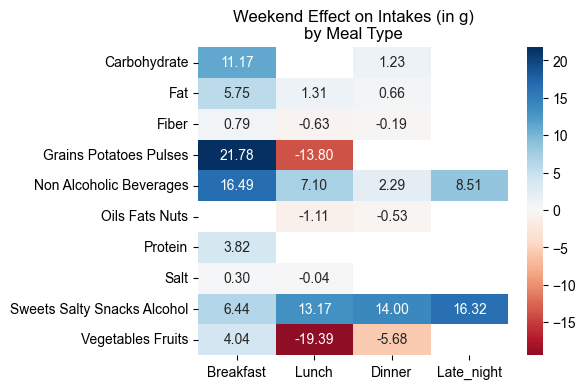

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
sns.heatmap(subset_pivot, cmap="RdBu", annot=True, fmt=".2f", center=0, ax=ax)
ax.set_title("Weekend Effect on Intakes (in g)\nby Meal Type")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()

fig.savefig(
    "../images/fig3/weekend_effect_on_nutrient_intake_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

## Weekend effect with time_since_last_eaten

In [10]:
mmm_no_small = merged_meals_with_meta[merged_meals_with_meta["energy_kcal_eaten"] > 0]
time_since_last_eaten = mmm_no_small.groupby("subject_key")["eaten_at"].apply(
    lambda x: x.diff()
)
mmm_no_small = mmm_no_small.assign(time_since_last_eaten=time_since_last_eaten.values)

## Removing Standardised Meals
# mmm_no_small = mmm_no_small[~(mmm_no_small['combined_name'].apply(lambda x: 'Tag standardised meal' in x))]

In [11]:
merged_meals_with_meta["eaten_date"].dtype

dtype('<M8[ns]')

In [12]:
filtered_meals = mmm_no_small[
    (mmm_no_small["time_since_last_eaten"] < pd.Timedelta(days=1))
]
filtered_meals = filtered_meals[filtered_meals["eaten_quantity_in_gram"] > 0]
filtered_meals["time_since_last_eaten"] = (
    filtered_meals["time_since_last_eaten"].dt.total_seconds() / 3600
)  # .astype(int)

filtered_meals["fastbroken"] = filtered_meals["time_since_last_eaten"] > 16
print(filtered_meals["meal_type"].value_counts())
print(filtered_meals.shape)
filtered_meals["fastbroken"] = filtered_meals["fastbroken"].astype(bool)

### Option1: Considering weekend meals from Friday 18:00 onwards
# filtered_meals['is_weekend'] = filtered_meals['eaten_at'].apply(lambda x: 'Weekend' if (x.weekday() == 4 and x.hour >= 18) or x.weekday() >= 5 else 'Weekday')

### Option2: Considering weekend meals only on Friday and Saturday
filtered_meals["day_of_week"] = filtered_meals["eaten_date"].dt.dayofweek
filtered_meals["is_weekend"] = filtered_meals["day_of_week"].apply(
    lambda x: "Weekend" if x in [5, 6] else "Weekday"
)

meal_type
Dinner        27918
Lunch         21349
Breakfast     14643
Late_night      951
Name: count, dtype: int64
(64861, 207)


In [13]:
# def effect_of_time_since_last_eaten_on_nutrient_old(
#     mydata, target_col, verbose=True, transform=True
# ):
#     data = mydata.copy()
#     data = data.sort_values("is_weekend")

#     data["is_weekend"] = data["is_weekend"].replace({"Weekend": 1, "Weekday": 0})

#     data["smoking"] = data["smoking"].replace(
#         {"smoking": 1, "non-smoker": 0, "former": 0}
#     )

#     # formula_base = f"{target_col} ~ age + gender + bmi + cohabitants + screen_hours + language + meal_type + time_since_last_eaten + C(is_weekend)"
#     # formula_base = f"{target_col} ~ C(is_weekend, Treatment(True)) + meal_type +" + " + ".join(covariates)
#     if transform:
#         formula_base = f"np.sqrt({target_col}) ~ C(is_weekend, Treatment(reference=0)) + C(meal_type, Treatment(reference='Breakfast')) + age + bmi + C(gender, Treatment(reference='female')) + C(language, Treatment(reference='latin')) + C(smoking, Treatment(reference=0)) + time_since_last_eaten"
#     else:
#         formula_base = f"{target_col} ~ C(is_weekend, Treatment(reference=0)) + C(meal_type, Treatment(reference='Breakfast')) + age + bmi + C(gender, Treatment(reference='female')) + C(language, Treatment(reference='latin')) + C(smoking, Treatment(reference=0)) + time_since_last_eaten"

#     model_test = mixedlm(formula_base, data, groups="subject_key")
#     result_test = model_test.fit()

#     if not result_test.converged:
#         print(f"Model did not converge for {target_col}")
#         return None

#     if verbose:
#         print(result_test.summary())

#         p_value = result_test.pvalues["Intercept"]
#         print(f"P-value for significance of {target_col}: {p_value}")

#     return result_test

In [14]:
def effect_of_time_since_last_eaten_on_nutrient(
    mydata, target_col, verbose=True, transform=True, exclude_zero_values=False
):
    """
    Analyze the effect of time since last eaten on a nutrient while controlling for other variables.

    Parameters:
    -----------
    mydata : pandas DataFrame
    target_col : str
        Name of the nutrient column to analyze
    verbose : bool
        Whether to print model summary
    transform : bool
        Whether to apply square root transformation to target variable

    Returns:
    --------
    statsmodels.regression.mixed_linear_model.MixedLMResults or None
    """
    # Work on a copy and reset index to ensure proper alignment
    data = mydata.copy()
    data = data.reset_index(drop=True)

    # Filter out invalid values
    if exclude_zero_values:
        data = data[data[target_col] > 0]
    else:
        data = data[data[target_col] >= 0]

    # Sort and encode categorical variables
    data = data.sort_values("is_weekend")
    data["is_weekend"] = data["is_weekend"].replace({"Weekend": 1, "Weekday": 0})
    data["smoking"] = data["smoking"].replace(
        {"smoking": 1, "non-smoker": 0, "former": 0}
    )

    # Construct formula
    independent_segment = (
        "C(is_weekend, Treatment(reference=0)) + "
        "C(meal_type, Treatment(reference='Breakfast')) + "
        "age + bmi + "
        "C(gender, Treatment(reference='female')) + "
        "C(language, Treatment(reference='latin')) + "
        "C(smoking, Treatment(reference=0)) + "
        "time_since_last_eaten"
    )
    independent_segment = independent_segment
    if transform:
        dependent_segment = f"np.sqrt({target_col})"
    else:
        dependent_segment = target_col

    formula_base = f"{dependent_segment} ~ {independent_segment}"

    # if transform:
    #     formula_base = (
    #         f"np.sqrt({target_col}) ~ "
    #         "C(is_weekend, Treatment(reference=0)) + "
    #         "C(meal_type, Treatment(reference='Breakfast')) + "
    #         "age + bmi + "
    #         "C(gender, Treatment(reference='female')) + "
    #         "C(language, Treatment(reference='latin')) + "
    #         "C(smoking, Treatment(reference=0)) + "
    #         "time_since_last_eaten"
    #     )
    # else:
    #     formula_base = (
    #         f"{target_col} ~ "
    #         "C(is_weekend, Treatment(reference=0)) + "
    #         "C(meal_type, Treatment(reference='Breakfast')) + "
    #         "age + bmi + "
    #         "C(gender, Treatment(reference='female')) + "
    #         "C(language, Treatment(reference='latin')) + "
    #         "C(smoking, Treatment(reference=0)) + "
    #         "time_since_last_eaten"
    #     )

    try:
        # Ensure all required columns exist
        required_cols = [
            "meal_type",
            "age",
            "bmi",
            "gender",
            "language",
            "smoking",
            "time_since_last_eaten",
            "subject_key",
        ]
        missing_cols = [col for col in required_cols if col not in data.columns]
        if missing_cols:
            print(f"Missing required columns: {missing_cols}")
            return None

        # Check for missing values in key columns
        na_counts = data[required_cols + [target_col]].isna().sum()
        if na_counts.any():
            print("Warning: Missing values found:")
            print(na_counts[na_counts > 0])
            # Drop rows with missing values in required columns
            data = data.dropna(subset=required_cols + [target_col])

        # Fit the model
        model_test = mixedlm(formula_base, data, groups="subject_key")
        result_test = model_test.fit()

        if not result_test.converged:
            print(f"Model did not converge for {target_col}")
            return None

        if verbose:
            print(result_test.summary())
            p_value = result_test.pvalues["time_since_last_eaten"]
            print(
                f"\nP-value for time since last eaten effect on {target_col}: {p_value}"
            )

            # Print sample sizes
            print("\nSample sizes:")
            print(f"Total observations: {len(data)}")
            print(f"Number of subjects: {len(data['subject_key'].unique())}")
            print("\nMeal type distribution:")
            print(data["meal_type"].value_counts())

        return result_test

    except Exception as e:
        print(f"Error fitting model: {str(e)}")
        print("Data shape:", data.shape)
        return None

In [15]:
def plot_mixed_model_effects_flexible(
    model_results,
    model_data,
    target_col,
    ax=None,
    exclude_terms=None,
    show_legend=True,
    plot_title=None,
):
    """
    Create a horizontal bar plot of back-transformed effects from a sqrt-transformed mixed model with confidence intervals.
    Uses different shapes to indicate significance levels.

    Parameters:
    -----------
    model_results : statsmodels mixed linear model results object
    target_mean : float
        Mean of the target variable (before sqrt transformation)
    ax : matplotlib axis object, optional
        Axis to plot on
    exclude_terms : list, optional
        List of terms to exclude from the plot (e.g., ['Intercept'])
    """
    if exclude_terms is None:
        exclude_terms = ["Intercept", "subject_key"]

    # Extract coefficients and standard errors
    coef = model_results.params
    se = model_results.bse

    # Initialize plot data list
    plot_data = []

    # Function to categorize terms
    def categorize_term(term):
        if "meal_type" in term:
            return "Meal Type Effects"
        elif any(demo in term.lower() for demo in ["gender", "age", "bmi"]):
            return "Demographic Effects"
        elif "weekend" in term.lower():
            return "Time Effects"
        elif "time_since_last" in term.lower():
            return "Time Effects"
        else:
            return "Other Effects"

    # Function to create readable label
    def create_label(term):
        if "meal_type" in term:
            meal = (
                term.split("[T.")[1].replace("]", "")
                if "[T." in term
                else term.split(".")[1].replace("]", "")
            )
            return f'{meal.replace("_", " ")} vs Breakfast'
        if "gender" in term:
            return f"Male vs Female"
        if "smoking" in term:
            return f"Smoker vs Non-smoker"
        if "language" in term:
            return f"German vs French/Italian"
        if "is_weekend" in term:
            return "Weekend vs Weekday"
        if term == "age":
            return "Age (per year)"
        if term == "bmi":
            return "BMI (per unit)"
        if term == "time_since_last_eaten":
            return "Time Since Last Meal (hours)"
        return term.replace("_", " ").capitalize()

    # Function to determine marker based on p-value
    def get_marker_for_pvalue(p_value):
        if p_value < 0.001:
            return "*"  # star
        elif p_value < 0.01:
            return "D"  # diamond
        elif p_value < 0.05:
            return "^"  # triangle
        else:
            return "o"  # circle

    # Process each term in the model
    for term in coef.index:
        if term not in exclude_terms and not term.startswith("subject_key"):
            category = categorize_term(term)
            label = create_label(term)

            # Back transform the effects
            effect, ci_lower, ci_upper = back_transform_effects(
                coef[term],
                se[term],
                eval_point=model_data.groupby("subject_key")[target_col].mean().mean(),
            )

            plot_data.append(
                {
                    "Effect": label,
                    "Estimate": effect,
                    "CI_lower": ci_lower,
                    "CI_upper": ci_upper,
                    "Category": category,
                    "P_value": model_results.pvalues[term],
                }
            )

    # Create DataFrame and continue with plotting
    plot_df = pd.DataFrame(plot_data)

    # Color scheme
    colors = {
        "Meal Type Effects": "#2ecc71",
        "Demographic Effects": "#3498db",
        "Time Effects": "#e74c3c",
        "Other Effects": "#95a5a6",
    }

    # Sort by category and effect name
    plot_df["abs_estimate"] = abs(plot_df["Estimate"])
    plot_df = plot_df.sort_values(["Category", "Effect"], ascending=[True, True])

    # Create the plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, len(plot_df) * 0.4 + 2))

    for i, row in enumerate(plot_df.itertuples()):
        # Plot CI
        ax.plot([row.CI_lower, row.CI_upper], [i, i], color="black", alpha=0.5)
        # Plot point estimate
        marker = get_marker_for_pvalue(row.P_value)
        ax.scatter(
            [row.Estimate],
            [i],
            color=colors[row.Category],
            marker=marker,
            s=100,
            zorder=3,
        )

    # Add reference line at 0
    ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)

    # Customize the plot
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df["Effect"])
    ax.set_xlabel("Effect Size")

    # Create legends
    if show_legend:
        used_categories = plot_df["Category"].unique()
        category_elements = [
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=colors[cat],
                label=cat,
                markersize=10,
            )
            for cat in used_categories
        ]

        significance_elements = [
            ax.scatter([], [], marker="*", color="gray", label="p < 0.001", s=150),
            ax.scatter([], [], marker="D", color="gray", label="p < 0.01", s=50),
            ax.scatter([], [], marker="^", color="gray", label="p < 0.05", s=50),
            ax.scatter([], [], marker="o", color="gray", label="N.S.", s=50),
        ]

        # Adjust figure size and add legends
        fig = ax.get_figure()
        fig.set_figwidth(fig.get_figwidth() * 1.3)

        first_legend = ax.legend(
            handles=category_elements,
            loc="center left",
            bbox_to_anchor=(1.0, 0.8),
            title="Effect Categories",
        )
        ax.add_artist(first_legend)
        ax.legend(
            handles=significance_elements,
            loc="center left",
            bbox_to_anchor=(1.1, 0.3),
            title="Significance Levels",
        )

        plt.tight_layout()
        plt.subplots_adjust(right=0.85)

    if plot_title:
        ax.set_title(plot_title)

    # Grid
    ax.grid(True, axis="x", linestyle="--", alpha=0.3)

    return ax

In [16]:
data_for_tsle = filtered_meals[
    (~filtered_meals["language"].isna()) & (filtered_meals["smoking"].notna())
]

# data_for_tsle = (
#     data_for_tsle.groupby(["subject_key", "eaten_date", "meal_type"])
#     .apply(lambda x: x.loc[x["energy_kcal_eaten"].idxmax()], include_groups=False)
#     .reset_index(drop=False)
# )

e_tsle_carb = effect_of_time_since_last_eaten_on_nutrient(
    data_for_tsle,
    "carb_eaten",
    verbose=True,
    transform=True,
)
e_tsle_fat = effect_of_time_since_last_eaten_on_nutrient(
    data_for_tsle,
    "fat_eaten",
    verbose=False,
    transform=True,
)
e_tsle_protein = effect_of_time_since_last_eaten_on_nutrient(
    data_for_tsle,
    "protein_eaten",
    verbose=False,
    transform=True,
)
e_tsle_alcohol = effect_of_time_since_last_eaten_on_nutrient(
    data_for_tsle,
    "alcohol_eaten",
    verbose=False,
    transform=True,
)
e_tsle_fiber = effect_of_time_since_last_eaten_on_nutrient(
    data_for_tsle,
    "fiber_eaten",
    verbose=False,
    transform=True,  # Note: not transformed due to non-convergence
)
e_tsle_energy = effect_of_time_since_last_eaten_on_nutrient(
    data_for_tsle,
    "energy_kcal_eaten",
    verbose=True,
    transform=True,
)

                                 Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             np.sqrt(carb_eaten)
No. Observations:               62852               Method:                         REML               
No. Groups:                     927                 Scale:                          5.3562             
Min. group size:                14                  Log-Likelihood:                 -142730.5492       
Max. group size:                186                 Converged:                      Yes                
Mean group size:                67.8                                                                   
-------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------

/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                                 Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           np.sqrt(energy_kcal_eaten)
No. Observations:            62853             Method:                       REML                      
No. Groups:                  927               Scale:                        48.1968                   
Min. group size:             14                Log-Likelihood:               -211499.5394              
Max. group size:             186               Converged:                    Yes                       
Mean group size:             67.8                                                                      
-------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------

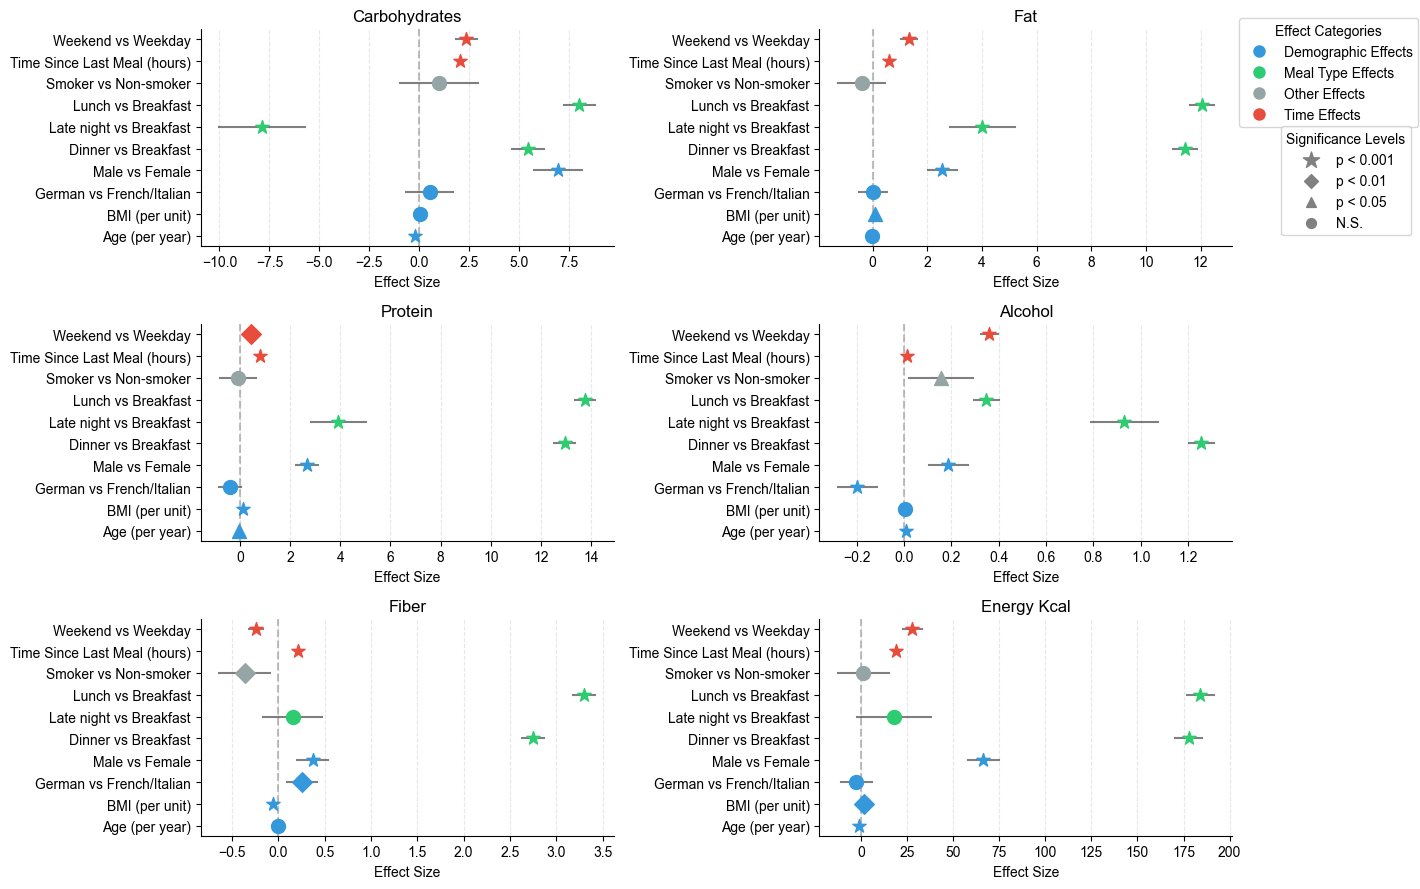

In [17]:
fig, ax = plt.subplots(ncols=2, nrows=3, figsize=(11, 9))
plot_mixed_model_effects_flexible(
    e_tsle_carb,
    data_for_tsle,
    "carb_eaten",
    ax=ax[0, 0],
    show_legend=False,
    plot_title="Carbohydrates",
)
plot_mixed_model_effects_flexible(
    e_tsle_fat,
    data_for_tsle,
    "fat_eaten",
    ax=ax[0, 1],
    show_legend=True,
    plot_title="Fat",
)
plot_mixed_model_effects_flexible(
    e_tsle_protein,
    data_for_tsle,
    "protein_eaten",
    ax=ax[1, 0],
    show_legend=False,
    plot_title="Protein",
)
plot_mixed_model_effects_flexible(
    e_tsle_alcohol,
    data_for_tsle,
    "alcohol_eaten",
    ax=ax[1, 1],
    show_legend=False,
    plot_title="Alcohol",
)

plot_mixed_model_effects_flexible(
    e_tsle_fiber,
    data_for_tsle,
    "fiber_eaten",
    ax=ax[2, 0],
    show_legend=False,
    plot_title="Fiber",
)
# ax[2, 0].set_visible(False)  # Hide the ax[2, 0] i.e. fiber plot

plot_mixed_model_effects_flexible(
    e_tsle_energy,
    data_for_tsle,
    "energy_kcal_eaten",
    ax=ax[2, 1],
    show_legend=False,
    plot_title="Energy Kcal",
)

plt.tight_layout()
sns.despine()
fig.savefig(
    "../images/fig3/effects_on_macronutrients.png", dpi=300, bbox_inches="tight"
)

In [18]:
e_tsle_energy.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                 Mixed Linear Model Regression Results
=======================================================================================================
Model:                       MixedLM           Dependent Variable:           np.sqrt(energy_kcal_eaten)
No. Observations:            62853             Method:                       REML                      
No. Groups:                  927               Scale:                        48.1968                   
Min. group size:             14                Log-Likelihood:               -211499.5394              
Max. group size:             186               Converged:                    Yes                       
Mean group size:             67.8                                                                      
-------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------------
Intercept                                                    13.383    0.352 37.968 0.000 12.692 14.074
C(is_weekend, Treatment(reference=0))[T.1]                    0.661    0.061 10.801 0.000  0.541  0.781
C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]      4.229    0.089 47.278 0.000  4.054  4.405
C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]  0.426    0.243  1.754 0.079 -0.050  0.902
C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]       4.375    0.089 48.923 0.000  4.200  4.550
C(gender, Treatment(reference='female'))[T.male]              1.578    0.103 15.357 0.000  1.376  1.779
C(language, Treatment(reference='latin'))[T.german]          -0.059    0.100 -0.589 0.556 -0.254  0.137
C(smoking, Treatment(reference=0))[T.smoker]                  0.030    0.166  0.179 0.858 -0.296  0.355
age                                                          -0.024    0.004 -5.576 0.000 -0.032 -0.015
bmi                                                           0.039    0.014  2.825 0.005  0.012  0.066
time_since_last_eaten                                         0.445    0.008 52.712 0.000  0.429  0.462
subject_key Var                                               1.502    0.016                           
=======================================================================================================

"""

In [19]:
e_tsle_carb.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                 Mixed Linear Model Regression Results
=======================================================================================================
Model:                          MixedLM             Dependent Variable:             np.sqrt(carb_eaten)
No. Observations:               62852               Method:                         REML               
No. Groups:                     927                 Scale:                          5.3562             
Min. group size:                14                  Log-Likelihood:                 -142730.5492       
Max. group size:                186                 Converged:                      Yes                
Mean group size:                67.8                                                                   
-------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------------
Intercept                                                     5.460    0.155 35.299 0.000  5.157  5.764
C(is_weekend, Treatment(reference=0))[T.1]                    0.175    0.020  8.569 0.000  0.135  0.215
C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]      0.405    0.030 13.521 0.000  0.346  0.464
C(meal_type, Treatment(reference='Breakfast'))[T.Late_night] -0.588    0.081 -7.233 0.000 -0.747 -0.429
C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]       0.597    0.030 19.955 0.000  0.539  0.656
C(gender, Treatment(reference='female'))[T.male]              0.520    0.046 11.363 0.000  0.430  0.609
C(language, Treatment(reference='latin'))[T.german]           0.039    0.045  0.866 0.387 -0.049  0.126
C(smoking, Treatment(reference=0))[T.smoker]                  0.073    0.074  0.991 0.322 -0.072  0.218
age                                                          -0.018    0.002 -9.325 0.000 -0.021 -0.014
bmi                                                           0.002    0.006  0.288 0.773 -0.010  0.014
time_since_last_eaten                                         0.150    0.003 53.017 0.000  0.145  0.156
subject_key Var                                               0.367    0.009                           
=======================================================================================================

"""

In [20]:
e_tsle_fat.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                 Mixed Linear Model Regression Results
=======================================================================================================
Model:                         MixedLM              Dependent Variable:              np.sqrt(fat_eaten)
No. Observations:              62846                Method:                          REML              
No. Groups:                    927                  Scale:                           3.8164            
Min. group size:               14                   Log-Likelihood:                  -131854.8768      
Max. group size:               186                  Converged:                       Yes               
Mean group size:               67.8                                                                    
-------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------------
Intercept                                                     2.187    0.105 20.869 0.000  1.981  2.392
C(is_weekend, Treatment(reference=0))[T.1]                    0.150    0.017  8.702 0.000  0.116  0.184
C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]      1.294    0.025 51.339 0.000  1.244  1.343
C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]  0.455    0.068  6.647 0.000  0.321  0.589
C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]       1.363    0.025 54.109 0.000  1.314  1.412
C(gender, Treatment(reference='female'))[T.male]              0.289    0.031  9.431 0.000  0.229  0.349
C(language, Treatment(reference='latin'))[T.german]           0.001    0.030  0.028 0.977 -0.058  0.059
C(smoking, Treatment(reference=0))[T.smoker]                 -0.045    0.050 -0.915 0.360 -0.142  0.052
age                                                          -0.002    0.001 -1.214 0.225 -0.004  0.001
bmi                                                           0.011    0.004  2.564 0.010  0.002  0.019
time_since_last_eaten                                         0.070    0.002 29.401 0.000  0.065  0.075
subject_key Var                                               0.141    0.005                           
=======================================================================================================

"""

In [21]:
e_tsle_protein.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                 Mixed Linear Model Regression Results
=======================================================================================================
Model:                         MixedLM            Dependent Variable:            np.sqrt(protein_eaten)
No. Observations:              62844              Method:                        REML                  
No. Groups:                    927                Scale:                         3.7672                
Min. group size:               14                 Log-Likelihood:                -131350.8696          
Max. group size:               186                Converged:                     Yes                   
Mean group size:               67.8                                                                    
-------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------------
Intercept                                                     1.388    0.095 14.651 0.000  1.202  1.573
C(is_weekend, Treatment(reference=0))[T.1]                    0.055    0.017  3.189 0.001  0.021  0.088
C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]      1.570    0.025 62.822 0.000  1.521  1.619
C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]  0.476    0.068  7.014 0.000  0.343  0.609
C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]       1.668    0.025 66.745 0.000  1.619  1.717
C(gender, Treatment(reference='female'))[T.male]              0.323    0.028 11.740 0.000  0.269  0.377
C(language, Treatment(reference='latin'))[T.german]          -0.046    0.027 -1.736 0.083 -0.099  0.006
C(smoking, Treatment(reference=0))[T.smoker]                 -0.009    0.045 -0.192 0.848 -0.096  0.079
age                                                          -0.002    0.001 -2.131 0.033 -0.005 -0.000
bmi                                                           0.017    0.004  4.598 0.000  0.010  0.024
time_since_last_eaten                                         0.099    0.002 42.116 0.000  0.095  0.104
subject_key Var                                               0.103    0.004                           
=======================================================================================================

"""

In [22]:
e_tsle_fiber.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                 Mixed Linear Model Regression Results
=======================================================================================================
Model:                         MixedLM             Dependent Variable:             np.sqrt(fiber_eaten)
No. Observations:              62848               Method:                         REML                
No. Groups:                    927                 Scale:                          1.0700              
Min. group size:               14                  Log-Likelihood:                 -92058.3478         
Max. group size:               186                 Converged:                      Yes                 
Mean group size:               67.8                                                                    
-------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------------
Intercept                                                     1.482    0.065 22.850 0.000  1.355  1.610
C(is_weekend, Treatment(reference=0))[T.1]                   -0.054    0.009 -5.887 0.000 -0.072 -0.036
C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]      0.613    0.013 45.855 0.000  0.587  0.640
C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]  0.034    0.036  0.950 0.342 -0.037  0.106
C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]       0.736    0.013 55.060 0.000  0.710  0.762
C(gender, Treatment(reference='female'))[T.male]              0.083    0.019  4.328 0.000  0.045  0.120
C(language, Treatment(reference='latin'))[T.german]           0.058    0.019  3.100 0.002  0.021  0.094
C(smoking, Treatment(reference=0))[T.smoker]                 -0.081    0.031 -2.622 0.009 -0.142 -0.020
age                                                           0.000    0.001  0.549 0.583 -0.001  0.002
bmi                                                          -0.014    0.003 -5.299 0.000 -0.019 -0.009
time_since_last_eaten                                         0.047    0.001 37.113 0.000  0.044  0.049
subject_key Var                                               0.062    0.004                           
=======================================================================================================

"""

In [23]:
e_tsle_alcohol.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                 Mixed Linear Model Regression Results
=======================================================================================================
Model:                         MixedLM            Dependent Variable:            np.sqrt(alcohol_eaten)
No. Observations:              62853              Method:                        REML                  
No. Groups:                    927                Scale:                         0.9150                
Min. group size:               14                 Log-Likelihood:                -87248.1242           
Max. group size:               186                Converged:                     Yes                   
Mean group size:               67.8                                                                    
-------------------------------------------------------------------------------------------------------
                                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------------
Intercept                                                    -0.306    0.067 -4.587 0.000 -0.436 -0.175
C(is_weekend, Treatment(reference=0))[T.1]                    0.166    0.008 19.714 0.000  0.150  0.183
C(meal_type, Treatment(reference='Breakfast'))[T.Dinner]      0.579    0.012 46.754 0.000  0.555  0.603
C(meal_type, Treatment(reference='Breakfast'))[T.Late_night]  0.429    0.034 12.778 0.000  0.364  0.495
C(meal_type, Treatment(reference='Breakfast'))[T.Lunch]       0.160    0.012 12.962 0.000  0.136  0.185
C(gender, Treatment(reference='female'))[T.male]              0.087    0.020  4.388 0.000  0.048  0.125
C(language, Treatment(reference='latin'))[T.german]          -0.091    0.019 -4.713 0.000 -0.128 -0.053
C(smoking, Treatment(reference=0))[T.smoker]                  0.072    0.032  2.244 0.025  0.009  0.134
age                                                           0.004    0.001  5.389 0.000  0.003  0.006
bmi                                                           0.002    0.003  0.722 0.470 -0.003  0.007
time_since_last_eaten                                         0.007    0.001  5.683 0.000  0.004  0.009
subject_key Var                                               0.070    0.004                           
=======================================================================================================

"""

## Fastbroken analysis



In [24]:
def process_meals_for_fastbroken(data, threshold=16):
    data = data.copy()
    data = data[(data["time_since_last_eaten"] < pd.Timedelta(days=1))]
    data["time_since_last_eaten"] = (
        data["time_since_last_eaten"].dt.total_seconds() / 3600
    )
    data["fastbroken"] = data["time_since_last_eaten"] > threshold
    data["fastbroken"] = data["fastbroken"].astype(bool)

    fastbroken_meals = data[data["fastbroken"] == True]
    non_fastbroken_meals = data[data["fastbroken"] == False]
    # print(fastbroken_meals['meal_type'].value_counts())

    return fastbroken_meals, non_fastbroken_meals, data

In [25]:
mmm_no_small = merged_meals_with_meta[merged_meals_with_meta["energy_kcal_eaten"] > 0]
time_since_last_eaten = mmm_no_small.groupby("subject_key")["eaten_at"].apply(
    lambda x: x.diff()
)
mmm_no_small = mmm_no_small.assign(time_since_last_eaten=time_since_last_eaten.values)

## Removing Standardised Meals
mmm_no_small = mmm_no_small[
    ~(mmm_no_small["combined_name"].apply(lambda x: "Tag standardised meal" in x))
]

In [26]:
_, _, x = process_meals_for_fastbroken(mmm_no_small, threshold=12)
x = x.dropna(subset=["language", "smoking"])
x = x[x["carb_eaten"] >= 0]

model = mixedlm(
    f"carb_eaten ~ fastbroken + meal_type:fastbroken + age + bmi + gender + language + smoking",
    x,
    groups="subject_key",
).fit()
print(model.summary())

/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/base

                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          carb_eaten  
No. Observations:           57827            Method:                      REML        
No. Groups:                 927              Scale:                       1106.1241   
Min. group size:            10               Log-Likelihood:              -285294.6060
Max. group size:            175              Converged:                   No          
Mean group size:            62.4                                                      
--------------------------------------------------------------------------------------
                                          Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                 43.635    2.031  21.489 0.000  39.655 47.614
fastbroken[T.True]                         9.766    0.772  12.647 0.

In [27]:
def analyze_fastbroken_effects(data, target_variable, threshold=12, transform=True):
    """
    Analyze the effects of fasting on a target variable across different meal types.

    Parameters:
    -----------
    data : DataFrame
        The input DataFrame (mmm_no_small)
    target_variable : str
        Name of the target variable (e.g., 'carb_eaten', 'protein_eaten')
    transform : bool
        Whether to apply sqrt transformation (default: True)

    Returns:
    --------
    tuple: (model, results_df)
        model: fitted mixed linear model
        results_df: DataFrame with back-transformed effects if transform=True
    """
    # Process data
    _, _, x = process_meals_for_fastbroken(data, threshold=threshold)
    x = x.dropna(subset=["language", "smoking"])
    x = x[x[target_variable] >= 0]

    # Create transformed variable if requested
    if transform:
        x[f"{target_variable}_sqrt"] = np.sqrt(x[target_variable])
        model_target = f"{target_variable}_sqrt"
    else:
        model_target = target_variable

    # Fit model
    model = mixedlm(
        f"{model_target} ~ fastbroken + meal_type:fastbroken + age + bmi + gender + language + smoking",
        x,
        groups="subject_key",
    ).fit()

    # Process results
    if transform:
        eval_point = x[target_variable].mean()
        results = []
        for name in model.params.index:
            if "fastbroken" in name:
                coef = model.params[name]
                se = model.bse[name]
                effect, ci_lower, ci_upper = back_transform_effects(
                    coef, se, eval_point
                )
                results.append(
                    {
                        "parameter": name,
                        "effect": effect,
                        "ci_lower": ci_lower,
                        "ci_upper": ci_upper,
                        "p_value": model.pvalues[name],
                    }
                )
        results_df = pd.DataFrame(results)
    else:
        results = []
        for name in model.params.index:
            if "fastbroken" in name:
                results.append(
                    {
                        "parameter": name,
                        "effect": model.params[name],
                        "ci_lower": model.params[name] - 1.96 * model.bse[name],
                        "ci_upper": model.params[name] + 1.96 * model.bse[name],
                        "p_value": model.pvalues[name],
                    }
                )
        results_df = pd.DataFrame(results)

    # Calculate differences between fastbroken True vs False
    meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]
    differences = []
    for meal in meal_types:
        true_effect = results_df[results_df["parameter"].str.contains(f"{meal}.*True")][
            "effect"
        ].values
        false_effect = results_df[
            results_df["parameter"].str.contains(f"{meal}.*False")
        ]["effect"].values
        if len(true_effect) > 0 and len(false_effect) > 0:
            diff = true_effect[0] - false_effect[0]
            differences.append({"meal_type": meal, "difference": diff})
    differences_df = pd.DataFrame(differences)

    return model, results_df, differences_df

In [28]:
model_fastbroken_carb, results_fastbroken_carb, diff_fastbroken_carb = (
    analyze_fastbroken_effects(mmm_no_small, "carb_eaten", transform=True)
)
print("\nCarb differences:")
print(diff_fastbroken_carb)
print("\nCarb effects:")
results_fastbroken_carb


Carb differences:
    meal_type  difference
0       Lunch    1.690899
1      Dinner    8.089117
2  Late_night   46.176044

Carb effects:


,parameter,effect,ci_lower,ci_upper,p_value
0,fastbroken[T.True],9.881547,8.419082,11.344012,4.934688e-40
1,meal_type[T.Dinner]:fastbroken[False],0.987371,0.108501,1.866240,2.766734e-02
2,meal_type[T.Late_night]:fastbroken[False],-11.690506,-13.966198,-9.414814,7.593040e-24
3,meal_type[T.Lunch]:fastbroken[False],4.090796,3.181462,5.000129,1.171474e-18
4,meal_type[T.Dinner]:fastbroken[True],9.076487,1.503584,16.649390,1.881613e-02
5,meal_type[T.Late_night]:fastbroken[True],34.485538,6.074643,62.896432,1.735614e-02
6,meal_type[T.Lunch]:fastbroken[True],5.781695,3.630380,7.933009,1.382686e-07


In [29]:
def create_combined_forest_plot(
    results_df, ax, title=None, show_legend=True, panel_text=None
):
    """
    Create a single forest plot showing both fastbroken True and False effects across meal types.

    Parameters:
    -----------
    results_df : pandas.DataFrame
        DataFrame containing the results with columns:
        - parameter: str, parameter name
        - effect: float, effect size
        - ci_lower: float, lower confidence interval
        - ci_upper: float, upper confidence interval
    figsize : tuple, optional
        Figure size in inches (width, height)
    save_path : str, optional
        Path to save the figure. If None, the plot will be displayed

    Returns:
    --------
    matplotlib.figure.Figure
        The generated figure containing the forest plot
    """
    # Prepare data for plotting
    meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]

    # Prepare data structures
    plot_data = []

    # Get base effect (Breakfast True)
    base_effect = results_df[results_df["parameter"] == "fastbroken[T.True]"].iloc[0]
    plot_data.append(
        {
            "meal_type": "Breakfast",
            "fastbroken": "True",
            "effect": base_effect["effect"],
            "ci_lower": base_effect["ci_lower"],
            "ci_upper": base_effect["ci_upper"],
        }
    )

    # Process other meal types
    for meal in meal_types[1:]:  # Skip Breakfast as it's handled above
        # Get True and False effects
        true_row = results_df[
            results_df["parameter"].str.contains(f"{meal}.*True")
        ].iloc[0]
        false_row = results_df[
            results_df["parameter"].str.contains(f"{meal}.*False")
        ].iloc[0]

        # Add True effect
        plot_data.append(
            {
                "meal_type": meal,
                "fastbroken": "True",
                "effect": true_row["effect"],
                "ci_lower": true_row["ci_lower"],
                "ci_upper": true_row["ci_upper"],
            }
        )

        # Add False effect
        plot_data.append(
            {
                "meal_type": meal,
                "fastbroken": "False",
                "effect": false_row["effect"],
                "ci_lower": false_row["ci_lower"],
                "ci_upper": false_row["ci_upper"],
            }
        )

    # Convert to DataFrame
    plot_df = pd.DataFrame(plot_data)

    # Plot settings
    dot_size = 30
    line_width = 2
    colors = {"True": "#2c7bb6", "False": "#d7191c"}
    y_offset = {"True": 0.1, "False": -0.1}

    # Calculate y positions
    unique_meals = meal_types
    y_positions = {meal: i for i, meal in enumerate(unique_meals)}

    # Create plot
    for fastbroken in ["True", "False"]:
        mask = plot_df["fastbroken"] == fastbroken
        data = plot_df[mask]

        # Plot points and lines
        for _, row in data.iterrows():
            y_pos = y_positions[row["meal_type"]] + y_offset[fastbroken]

            # Plot confidence interval
            ax.hlines(
                y=y_pos,
                xmin=row["ci_lower"],
                xmax=row["ci_upper"],
                color=colors[fastbroken],
                linewidth=line_width,
            )

            # Plot point estimate
            ax.scatter(
                row["effect"],
                y_pos,
                s=dot_size,
                color=colors[fastbroken],
                label=f"Fastbroken {fastbroken}",
            )

    # Remove duplicate labels
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys())

    # Customize plot
    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()))
    ax.set_xlabel("Effect Size")
    ax.set_title(title)

    # Add reference line
    ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)

    # Add grid
    ax.yaxis.grid(True, alpha=0.3)

    if panel_text:
        ax.text(
            -0.1,
            1.15,
            panel_text,
            transform=ax.transAxes,
            fontsize=14,
            va="top",
            fontweight="bold",
        )

    return fig

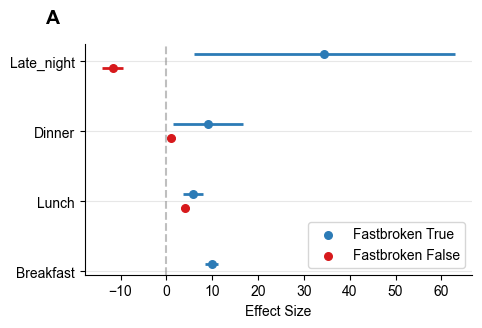

In [30]:
fig, ax = plt.subplots(figsize=(5, 3))
fig = create_combined_forest_plot(results_fastbroken_carb, ax, panel_text="A")
sns.despine()
plt.show()

In [31]:
model_fastbroken_protein, results_fastbroken_protein, diff_fastbroken_protein = (
    analyze_fastbroken_effects(mmm_no_small, "protein_eaten", transform=True)
)

model_fastbroken_fat, results_fastbroken_fat, diff_fastbroken_fat = (
    analyze_fastbroken_effects(mmm_no_small, "fat_eaten", transform=True)
)

model_fastbroken_alcohol, results_fastbroken_alcohol, diff_fastbroken_alcohol = (
    analyze_fastbroken_effects(mmm_no_small, "alcohol_eaten", transform=True)
)

model_fastbroken_fiber, results_fastbroken_fiber, diff_fastbroken_fiber = (
    analyze_fastbroken_effects(mmm_no_small, "fiber_eaten", transform=True)
)

model_fastbroken_energy, results_fastbroken_energy, diff_fastbroken_energy = (
    analyze_fastbroken_effects(mmm_no_small, "energy_kcal_eaten", transform=True)
)

/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/statsmodels/base

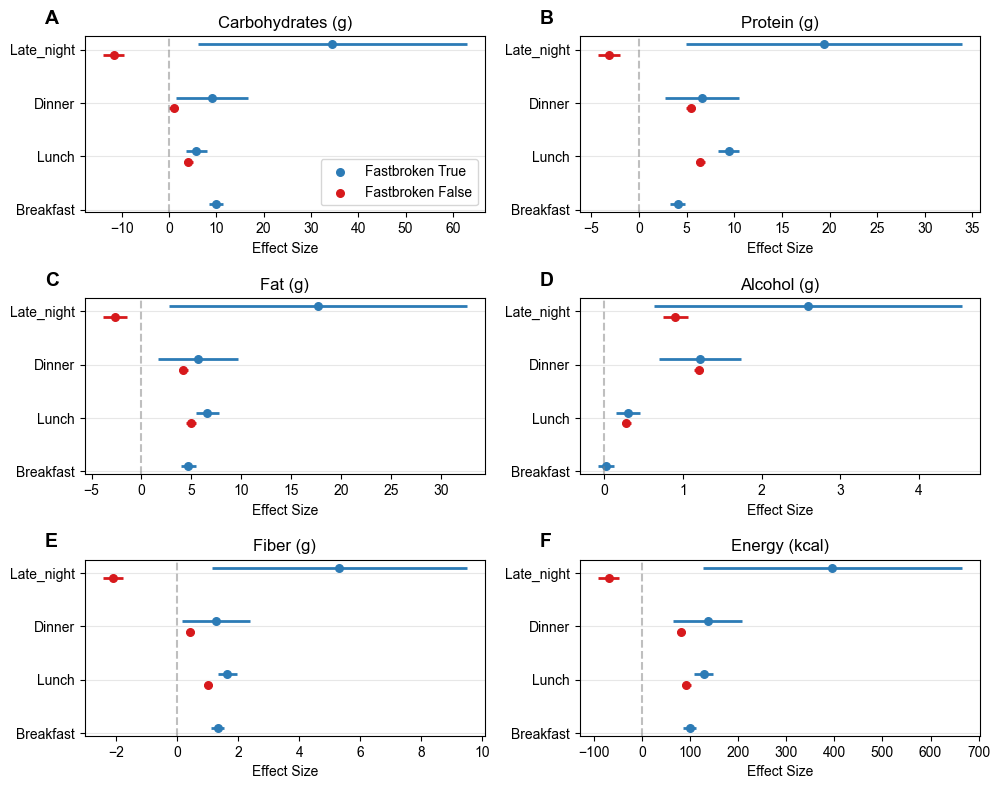

In [32]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))
create_combined_forest_plot(
    results_fastbroken_carb,
    ax[0, 0],
    title="Carbohydrates (g)",
    panel_text="A",
)
create_combined_forest_plot(
    results_fastbroken_protein,
    ax[0, 1],
    title="Protein (g)",
    show_legend=False,
    panel_text="B",
)
create_combined_forest_plot(
    results_fastbroken_fat, ax[1, 0], title="Fat (g)", show_legend=False, panel_text="C"
)
create_combined_forest_plot(
    results_fastbroken_alcohol,
    ax[1, 1],
    title="Alcohol (g)",
    show_legend=False,
    panel_text="D",
)
create_combined_forest_plot(
    results_fastbroken_fiber,
    ax[2, 0],
    title="Fiber (g)",
    show_legend=False,
    panel_text="E",
)
create_combined_forest_plot(
    results_fastbroken_energy,
    ax[2, 1],
    title="Energy (kcal)",
    show_legend=False,
    panel_text="F",
)

# sns.despine()
plt.tight_layout()

fig.savefig(
    "../images/fig5/effects_on_macronutrients_fastbroken.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [33]:
results_fastbroken_energy

,parameter,effect,ci_lower,ci_upper,p_value
0,fastbroken[T.True],99.103688,85.241740,112.965637,1.303663e-44
1,meal_type[T.Dinner]:fastbroken[False],81.629917,73.302208,89.957627,2.919118e-82
2,meal_type[T.Late_night]:fastbroken[False],-69.210921,-90.773671,-47.648171,3.152253e-10
3,meal_type[T.Lunch]:fastbroken[False],92.661410,84.044057,101.278764,1.330525e-98
4,meal_type[T.Dinner]:fastbroken[True],136.643663,64.896875,208.390451,1.893088e-04
5,meal_type[T.Late_night]:fastbroken[True],395.695304,126.419101,664.971508,3.974535e-03
6,meal_type[T.Lunch]:fastbroken[True],128.474337,108.097786,148.850887,4.419933e-35
